# Bayesian Optimization for LightGBM
Completed case study — Jacob Paul


Use Bayesian optimization to maximize a three-fold cross-validation ROC-AUC for flight-delay classification. We keep the requested **2 initial random evaluations + 5 Bayesian evaluations**. We also reserve 20% of the labeled data as an untouched holdout until selection is complete. The separate 100,000-row test file has no labels, so its accuracy/AUC cannot be measured.

**Changes from the starter:** remove unused CatBoost and global warning suppression; learn category vocabularies and frequency counts inside training folds; convert HHMM to minutes before cyclic encoding; remove the duplicate `min_child_samples`/`min_data_in_leaf` search dimension; use practical laptop-sized bounds and early stopping. Results describe this finite search, not a proven global optimum.

For local use, install `requirements.txt` in Python 3.12 and restart your kernel. Keep both CSVs inside `data/` beside this notebook; files beside the notebook are also supported. The next cell installs missing dependencies into the active Python environment and verifies the imports. Internet access is needed for the initial installation; subsequent runs skip installed packages.


In [1]:
# Install missing dependencies into the Python environment running this notebook.
# Requires internet access for the first run; later runs skip installed packages.
import importlib.util
import importlib
import subprocess
import sys

required_packages = {
    'lightgbm': 'lightgbm==4.7.0',
    'bayes_opt': 'bayesian-optimization==3.3.0',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'sklearn': 'scikit-learn',
}
missing_packages = [package for module, package in required_packages.items()
                    if importlib.util.find_spec(module) is None]
print('Active Python:', sys.executable)
if missing_packages:
    print('Installing missing packages:', ', '.join(missing_packages))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing_packages])
    importlib.invalidate_caches()
else:
    print('All required packages are already installed.')

# Verify imports, including LightGBM's native library and the acquisition API.
import lightgbm
from bayes_opt import BayesianOptimization, acquisition
print('Setup complete. Continue running the remaining cells.')

Active Python: /opt/anaconda3/bin/python
Installing missing packages: lightgbm==4.7.0, bayesian-optimization==3.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 4.8 MB/s  0:00:00m 4.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [bayesian-optimization]
Setup complete. Continue running the remaining cells.


In [2]:
from pathlib import Path
import sys, json, time, importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from bayes_opt import BayesianOptimization, acquisition
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, RocCurveDisplay, ConfusionMatrixDisplay
from IPython.display import display
SEED = 42
N_THREADS = 2
MAX_ROUNDS = 300
EARLY_STOPPING_ROUNDS = 30
np.random.seed(SEED)
print('Python:', sys.version.split()[0])
for package in ['lightgbm','bayesian-optimization','pandas','numpy','scikit-learn']:
    print(package, importlib.metadata.version(package))


Python: 3.14.6
lightgbm 4.7.0
bayesian-optimization 3.3.0
pandas 3.0.3
numpy 2.4.6
scikit-learn 1.9.0


In [3]:
print('Working directory:', Path.cwd())
print('Notebook inputs are loaded with relative paths below.')


Working directory: /Users/jacobpaul/Documents/SpringBoard/Github/bayesian-optimization-flight-delays
Notebook inputs are loaded with relative paths below.


## How does Bayesian optimization work?

Bayesian optimization builds a probabilistic surrogate of an expensive objective. Here a Gaussian process estimates performance and uncertainty across hyperparameters. An acquisition function chooses a candidate, the real objective evaluates it, and the new observation updates the search. The method balances exploring uncertain regions and exploiting promising ones.


We use Upper Confidence Bound (UCB), approximately `predicted mean + kappa × predicted standard deviation`, with `kappa=2.576`. This encourages both high predicted quality and exploration. The self-contained plots below show sampled points and best-observed objective values; they do not claim to display the GP posterior.


## Let's look at a simple example

The optimizer needs an objective function and parameter bounds. It **maximizes** the returned value. Return ROC-AUC directly because higher is better; negate a loss such as log loss if minimizing it. There is no rule that all metrics should be negated.


Here we define our simple function we want to optimize.

In [4]:
def simple_func(a, b):
    return a + b

Now, we define our bounds of the parameters to optimize, within the Bayesian optimizer.

In [5]:
optimizer = BayesianOptimization(f=simple_func, pbounds={'a': (1, 3), 'b': (4, 7)}, random_state=SEED, acquisition_function=acquisition.UpperConfidenceBound(kappa=2.576), verbose=2)


These are the main parameters of this function:

* **n_iter:** This is how many steps of Bayesian optimization you want to perform. The more steps, the more likely you are to find a good maximum.

* **init_points:** This is how many steps of random exploration you want to perform. Random exploration can help by diversifying the exploration space.

Run three random initial evaluations and two Bayesian evaluations. The arguments control evaluation counts, not values of a and b.


In [6]:
optimizer.maximize(init_points=3, n_iter=2)


|   iter    |  target   |     a     |     b     |
-------------------------------------------------
| 1         | 8.6012231 | 1.7490802 | 6.8521429 |
| 2         | 8.2599633 | 2.4639878 | 5.7959754 |
| 3         | 5.7800208 | 1.3120372 | 4.4679835 |
| 4         | 9.7870954 | 2.8160391 | 6.9710562 |
| 5         | 9.5403424 | 3.0       | 6.5403424 |


Great, now let's print the best parameters and the associated maximized target.

Best observed result: {'target': np.float64(9.787095427830408), 'params': {'a': np.float64(2.816039163853198), 'b': np.float64(6.97105626397721)}}
Known analytic maximum: a=3, b=7, objective=10.


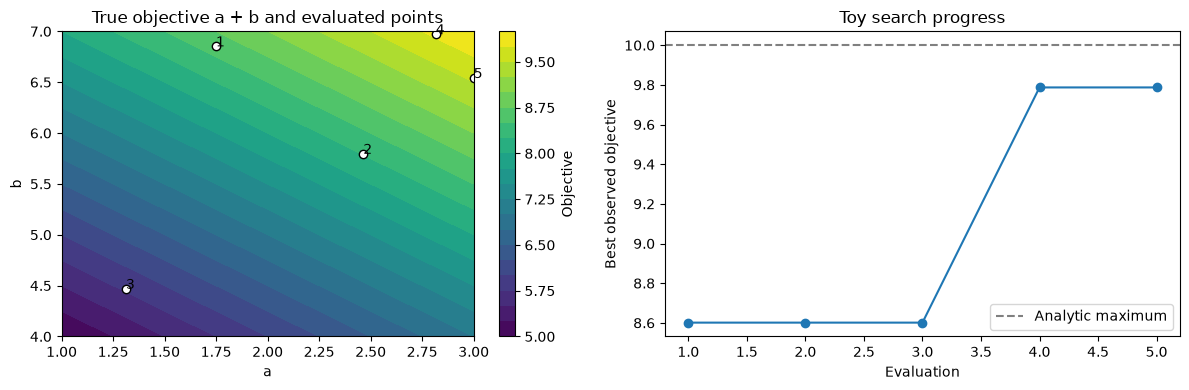

In [7]:
print('Best observed result:', optimizer.max)
print('Known analytic maximum: a=3, b=7, objective=10.')
a_grid, b_grid = np.meshgrid(np.linspace(1,3,80), np.linspace(4,7,80))
fig, axes = plt.subplots(1,2,figsize=(12,4))
contour = axes[0].contourf(a_grid,b_grid,a_grid+b_grid,levels=20,cmap='viridis')
for step, result in enumerate(optimizer.res,1):
    axes[0].scatter(result['params']['a'],result['params']['b'],c='white',edgecolors='black')
    axes[0].annotate(str(step),(result['params']['a'],result['params']['b']))
axes[0].set(xlabel='a',ylabel='b',title='True objective a + b and evaluated points')
fig.colorbar(contour,ax=axes[0],label='Objective')
toy_scores = [r['target'] for r in optimizer.res]
axes[1].plot(range(1,6),np.maximum.accumulate(toy_scores),marker='o')
axes[1].axhline(10,color='gray',linestyle='--',label='Analytic maximum')
axes[1].set(xlabel='Evaluation',ylabel='Best observed objective',title='Toy search progress')
axes[1].legend();plt.tight_layout();plt.show()


## Test it on real data using the Light GBM

The dataset we will be working with is the famous flight departures dataset. Our modeling goal will be to predict if a flight departure is going to be delayed by 15 minutes based on the other attributes in our dataset. As part of this modeling exercise, we will use Bayesian hyperparameter optimization to identify the best parameters for our model.

**<font color='teal'> You can load the zipped csv files just as you would regular csv files using Pandas read_csv. In the next cell load the train and test data into two seperate dataframes. </font>**


In [8]:
def input_path(name):
    paths = [Path('data')/name, Path(name), Path('../data')/name]
    path = next((p for p in paths if p.is_file()),None)
    if path is None: raise FileNotFoundError(f'Place {name} in data/ beside the notebook.')
    return path
train_df = pd.read_csv(input_path('flight_delays_train.csv'))
test_df = pd.read_csv(input_path('flight_delays_test.csv'))
assert train_df.shape == (100000,9) and test_df.shape == (100000,8)
assert 'dep_delayed_15min' not in test_df
print('Training:',train_df.shape,'Unlabeled test:',test_df.shape)
print('Missing values:',train_df.isna().sum().sum(),test_df.isna().sum().sum())


Training: (100000, 9) Unlabeled test: (100000, 8)
Missing values: 0 0


**<font color='teal'> Print the top five rows of the train dataframe and review the columns in the data. </font>**

In [9]:
train_df.head()

,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
0,c-8,c-21,c-7,1934,AA,ATL,DFW,732,N
1,c-4,c-20,c-3,1548,US,PIT,MCO,834,N
2,c-9,c-2,c-5,1422,XE,RDU,CLE,416,N
3,c-11,c-25,c-6,1015,OO,DEN,MEM,872,N
4,c-10,c-7,c-6,1828,WN,MDW,OMA,423,Y


**<font color='teal'> Use the describe function to review the numeric columns in the train dataframe. </font>**

In [10]:
display(train_df.describe())
print('Label counts:');print(train_df.dep_delayed_15min.value_counts())
print('Departure times greater than 2400:',train_df.DepTime.gt(2400).sum())


,DepTime,Distance
count,100000.000000,100000.00000
mean,1341.523880,729.39716
std,476.378445,574.61686
min,1.000000,30.00000
25%,931.000000,317.00000
50%,1330.000000,575.00000
75%,1733.000000,957.00000
max,2534.000000,4962.00000


Label counts:
dep_delayed_15min
N    80956
Y    19044
Name: count, dtype: int64
Departure times greater than 2400: 17


`DepTime` uses HHMM, so 1934 means 19:34, not 19.34 hours. Convert to minutes and use a 1440-minute period. The 17 training times above 2400 are retained as next-day clock representations (an explicit assumption); 2400 wraps to midnight.

**Availability limitation:** the files do not establish whether departure time is scheduled or actual. If it is actual, it is unavailable for advance prediction and may encode the delay itself. We retain it for this exercise, but these results are not evidence of an operational advance-warning model. A deployment study must use verified as-of-decision features and chronological validation.


 **<font color='teal'>The response variable is 'dep_delayed_15min' which is a categorical column, so we need to map the Y for yes and N for no values to 1 and 0. Run the code in the next cell to do this.</font>**

In [11]:
y_train = train_df['dep_delayed_15min'].map({'Y':1,'N':0})
assert y_train.notna().all()
y_train = y_train.astype('int8')
print('Delayed fraction:',y_train.mean())


Delayed fraction: 0.19044


## Feature engineering
Row-level features are deterministic and do not learn from other rows. Frequency maps and categorical vocabularies are fitted separately on each training fold. Unknown categories use -1 (LightGBM missing category), and unknown frequency groups use zero. A day-of-week value of 6 or 7 is treated as a weekend under the assumed Monday=1 convention; the data do not identify public holidays.


In [12]:
CAT_COLUMNS = ['Month','DayOfWeek','UniqueCarrier','Origin','Dest','flight','flightUC','DestUC','OriginUC']
COUNT_GROUPS = {
    'airport_dest_per_month':['Dest','Month'], 'airport_origin_per_month':['Origin','Month'],
    'airport_dest_count':['Dest'], 'airport_origin_count':['Origin'],
    'carrier_count':['UniqueCarrier'], 'carrier_count_per_month':['UniqueCarrier','Month']}

def feature_eng(df):
    out = df.copy()
    for c in ['Month','DayofMonth','DayOfWeek']:
        out[c] = out[c].astype(str).str.split('-').str[-1].astype('int32')
    assert out.Month.between(1,12).all() and out.DayOfWeek.between(1,7).all()
    assert out.DayofMonth.between(1,31).all()
    hhmm = out.pop('DepTime').astype(int)
    assert ((hhmm % 100) < 60).all() and (hhmm >= 0).all()
    minutes = (hhmm // 100) * 60 + hhmm % 100
    clock_minutes = minutes % 1440
    out['hour'] = clock_minutes // 60
    out['deptime_sin'] = np.sin(2*np.pi*clock_minutes/1440)
    out['deptime_cos'] = np.cos(2*np.pi*clock_minutes/1440)
    out['begin_of_month'] = (out.DayofMonth < 10).astype(int)
    out['middle_of_month'] = out.DayofMonth.between(10,19).astype(int)
    out['end_of_month'] = (out.DayofMonth >= 20).astype(int)
    for name,lo,hi in [('night',0,6),('morning',7,11),('day',12,18),('evening',19,23)]:
        out[name] = out.hour.between(lo,hi).astype(int)
    for name,months in [('winter',[12,1,2]),('spring',[3,4,5]),('summer',[6,7,8]),('autumn',[9,10,11])]:
        out[name] = out.Month.isin(months).astype(int)
    out['weekend'] = out.DayOfWeek.isin([6,7]).astype(int)
    out['weekday'] = 1-out.weekend
    out['flight'] = out.Origin+'_'+out.Dest
    out['flightUC'] = out.flight+'_'+out.UniqueCarrier
    out['DestUC'] = out.Dest+'_'+out.UniqueCarrier
    out['OriginUC'] = out.Origin+'_'+out.UniqueCarrier
    return out

def group_keys(frame, columns):
    return list(frame[columns].itertuples(index=False,name=None))

def fit_feature_state(frame):
    state = {'categories':{},'counts':{},'n_fit':len(frame)}
    for column in CAT_COLUMNS:
        state['categories'][column] = {v:i for i,v in enumerate(sorted(frame[column].unique()))}
    for name, columns in COUNT_GROUPS.items():
        state['counts'][name] = pd.Series(group_keys(frame,columns)).value_counts().to_dict()
    return state

def transform_features(frame,state):
    out = frame.copy()
    for name, columns in COUNT_GROUPS.items():
        out[name] = [state['counts'][name].get(k,0) for k in group_keys(frame,columns)]
    for column in CAT_COLUMNS:
        out[column] = frame[column].map(state['categories'][column]).fillna(-1).astype('int32')
    assert np.isfinite(out.to_numpy(dtype=float)).all()
    return out


Concatenate only for deterministic row-level engineering. No frequency counts or category vocabularies are learned from this combined dataframe.


In [13]:
full_df = pd.concat([train_df.drop(columns='dep_delayed_15min'),test_df],ignore_index=True)
full_df = feature_eng(full_df)
assert len(full_df) == len(train_df)+len(test_df)


The deterministic features are created above. Reserve a stratified 20% labeled holdout before fitting any learned feature transformations.


In [14]:
labeled_features = full_df.iloc[:len(train_df)].reset_index(drop=True)
unlabeled_features = full_df.iloc[len(train_df):].reset_index(drop=True)
fit_idx, holdout_idx = train_test_split(np.arange(len(train_df)),test_size=0.20,stratify=y_train,random_state=SEED)
X_development = labeled_features.iloc[fit_idx].copy()
y_development = y_train.iloc[fit_idx].copy()
X_holdout_raw = labeled_features.iloc[holdout_idx].copy()
y_holdout = y_train.iloc[holdout_idx].copy()
assert set(fit_idx).isdisjoint(holdout_idx)
print('Optimization development rows:',len(fit_idx),'Reserved holdout:',len(holdout_idx))


Optimization development rows: 80000 Reserved holdout: 20000


Fit a development-only feature state for the later holdout evaluation. Cross-validation uses separate, fold-specific states below.


In [15]:
development_state = fit_feature_state(X_development)
X_train = transform_features(X_development,development_state)
X_holdout = transform_features(X_holdout_raw,development_state)
X_test = transform_features(unlabeled_features,development_state)
assert list(X_train.columns) == list(X_holdout.columns) == list(X_test.columns)
print('Engineered feature count:',X_train.shape[1])


Engineered feature count: 33


Create a list of the categorical features.

In [16]:
categorical_features = CAT_COLUMNS.copy()


Let's build a light GBM model to test the bayesian optimizer.

LightGBM is a gradient-boosted tree implementation. We use its native categorical-feature support with integer category codes and ROC-AUC as the ranking metric. We do not scale numeric features or apply class weights; imbalance is reflected in additional precision-recall and threshold metrics at evaluation. Better accuracy is not guaranteed merely by choosing this library.


### Cross-validation objective

Three fixed stratified folds make candidate scores comparable. Each fold learns its own categories and frequency counts; fold validation data never contribute to these transformations. We use an explicit training loop rather than `lightgbm.cv` so fold-specific transformations stay isolated.

`min_child_samples` is an alias of `min_data_in_leaf`, so only the latter is optimized. Integer-valued suggestions are rounded, and leaves are capped at `2**max_depth`. Raw suggestions and effective parameters are both retained. We use 300 boosting rounds maximum, learning rate 0.05, and 30-round early stopping. These finite budgets may limit performance; they are not a claim of exhaustive tuning.


In [17]:
cv = StratifiedKFold(n_splits=3,shuffle=True,random_state=SEED)
fold_cache = []
for train_pos, valid_pos in cv.split(X_development,y_development):
    fold_train, fold_valid = X_development.iloc[train_pos], X_development.iloc[valid_pos]
    state = fit_feature_state(fold_train)
    assert state['n_fit'] == len(train_pos)
    fold_cache.append((transform_features(fold_train,state),y_development.iloc[train_pos],
                       transform_features(fold_valid,state),y_development.iloc[valid_pos]))

BASE_PARAMS = dict(objective='binary',metric='auc',learning_rate=0.05,verbosity=-1,
                   num_threads=N_THREADS,seed=SEED,deterministic=True,force_col_wise=True)
trial_records = []
def effective_params(num_leaves,max_depth,lambda_l2,lambda_l1,min_data_in_leaf):
    depth = int(round(max_depth))
    return dict(num_leaves=min(int(round(num_leaves)),2**depth),max_depth=depth,
                lambda_l2=float(lambda_l2),lambda_l1=float(lambda_l1),min_data_in_leaf=int(round(min_data_in_leaf)))

def evaluate_params(params):
    scores, iterations = [], []
    for fold_x, fold_y, valid_x, valid_y in fold_cache:
        train_set = lgb.Dataset(fold_x,label=fold_y,categorical_feature=categorical_features)
        valid_set = lgb.Dataset(valid_x,label=valid_y,categorical_feature=categorical_features,reference=train_set)
        model = lgb.train({**BASE_PARAMS,**params},train_set,num_boost_round=MAX_ROUNDS,
            valid_sets=[valid_set],valid_names=['cv_valid'],
            callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS,verbose=False)])
        probability = model.predict(valid_x,num_iteration=model.best_iteration,num_threads=N_THREADS)
        scores.append(roc_auc_score(valid_y,probability));iterations.append(model.best_iteration)
    return scores,iterations

def lgb_eval(num_leaves,max_depth,lambda_l2,lambda_l1,min_data_in_leaf):
    start = time.perf_counter()
    params = effective_params(num_leaves,max_depth,lambda_l2,lambda_l1,min_data_in_leaf)
    scores,iterations = evaluate_params(params)
    trial_records.append(dict(trial=len(trial_records)+1,mean_auc=float(np.mean(scores)),
        std_auc=float(np.std(scores)),fold_auc=scores,best_iterations=iterations,
        seconds=time.perf_counter()-start,**params))
    print(f"Trial {len(trial_records)}: mean CV AUC={np.mean(scores):.5f}; rounds={iterations}")
    return float(np.mean(scores))


Run the requested seven evaluations: two random initial points and five Bayesian steps. Practical bounds replace the starter's up-to-4,000-leaf trees and duplicated leaf-size settings. L1/L2 penalties span 0–5. A seven-evaluation budget in five dimensions is exploratory and may miss better settings.


In [18]:
bounds = {'num_leaves':(16,128),'max_depth':(4,10),'lambda_l2':(0,5),
          'lambda_l1':(0,5),'min_data_in_leaf':(30,300)}
lgbBO = BayesianOptimization(f=lgb_eval,pbounds=bounds,random_state=SEED,
    acquisition_function=acquisition.UpperConfidenceBound(kappa=2.576),verbose=2)
lgbBO.maximize(init_points=2,n_iter=5)
assert len(lgbBO.res) == len(trial_records) == 7


|   iter    |  target   | num_le... | max_depth | lambda_l2 | lambda_l1 | min_da... |
-------------------------------------------------------------------------------------
Trial 1: mean CV AUC=0.71926; rounds=[42, 26, 40]
| 1         | 0.7192583 | 57.948493 | 9.7042858 | 3.6599697 | 2.9932924 | 72.125032 |
Trial 2: mean CV AUC=0.71882; rounds=[74, 71, 66]
| 2         | 0.7188199 | 33.471386 | 4.3485016 | 4.3308807 | 3.0055750 | 221.17959 |
Trial 3: mean CV AUC=0.71892; rounds=[51, 30, 47]
| 3         | 0.7189192 | 55.893747 | 9.4506803 | 4.0424475 | 2.8587340 | 72.521927 |
Trial 4: mean CV AUC=0.71797; rounds=[67, 63, 89]
| 4         | 0.7179691 | 55.904811 | 4.5077103 | 2.0957762 | 0.4348280 | 210.76990 |
Trial 5: mean CV AUC=0.71902; rounds=[46, 32, 52]
| 5         | 0.7190217 | 60.893214 | 7.3542487 | 1.9546088 | 3.9354235 | 73.409943 |
Trial 6: mean CV AUC=0.71881; rounds=[39, 29, 51]
| 6         | 0.7188092 | 60.020875 | 9.3173575 | 1.6611029 | 1.3516186 | 68.996079 |
Trial 7: mea

 **<font color='teal'> Print the best result by using the '.max' function.</font>**

In [19]:
print('Best raw suggestion and CV objective:')
display(lgbBO.max)
best_params = effective_params(**lgbBO.max['params'])
print('Effective parameters used by LightGBM:',best_params)


Best raw suggestion and CV objective:


{'target': np.float64(0.7192583429123722),
 'params': {'num_leaves': np.float64(57.948493310904595),
  'max_depth': np.float64(9.704285838459498),
  'lambda_l2': np.float64(3.6599697090570253),
  'lambda_l1': np.float64(2.993292420985183),
  'min_data_in_leaf': np.float64(72.12503291945787)}}

Effective parameters used by LightGBM: {'num_leaves': 58, 'max_depth': 10, 'lambda_l2': 3.6599697090570253, 'lambda_l1': 2.993292420985183, 'min_data_in_leaf': 72}


Review the process at each step by using the '.res[0]' function.

In [20]:
display(lgbBO.res[0])
search_history = pd.DataFrame(trial_records)
display(search_history.drop(columns=['fold_auc','best_iterations']))


{'target': np.float64(0.7192583429123722),
 'params': {'num_leaves': np.float64(57.948493310904595),
  'max_depth': np.float64(9.704285838459498),
  'lambda_l2': np.float64(3.6599697090570253),
  'lambda_l1': np.float64(2.993292420985183),
  'min_data_in_leaf': np.float64(72.12503291945787)}}

,trial,mean_auc,std_auc,seconds,num_leaves,max_depth,lambda_l2,lambda_l1,min_data_in_leaf
0,1,0.719258,0.000762,1.415895,58,10,3.659970,2.993292,72
1,2,0.718820,0.000997,1.074754,16,4,4.330881,3.005575,221
2,3,0.718919,0.000993,1.583205,56,9,4.042448,2.858734,73
3,4,0.717969,0.000960,1.432656,32,5,2.095776,0.434828,211
4,5,0.719022,0.000809,1.402904,61,7,1.954609,3.935424,73
5,6,0.718809,0.000963,1.591487,60,9,1.661103,1.351619,69
6,7,0.718900,0.000984,1.512885,60,10,3.696455,2.167480,75


## Visualize the search
The left chart shows each trial and the best score observed so far. Error bars are standard deviations across three folds, not confidence intervals. The right chart shows one searched parameter against performance; other parameters changed too, so it does not isolate that parameter's causal effect.


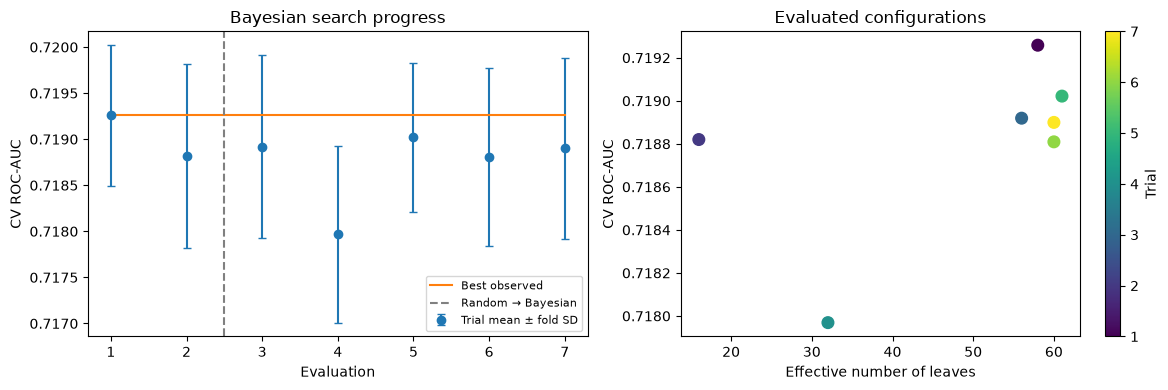

In [21]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].errorbar(search_history.trial,search_history.mean_auc,yerr=search_history.std_auc,fmt='o',capsize=3,label='Trial mean ± fold SD')
axes[0].plot(search_history.trial,search_history.mean_auc.cummax(),label='Best observed')
axes[0].axvline(2.5,color='gray',linestyle='--',label='Random → Bayesian')
axes[0].set(xlabel='Evaluation',ylabel='CV ROC-AUC',title='Bayesian search progress');axes[0].legend(fontsize=8)
points=axes[1].scatter(search_history.num_leaves,search_history.mean_auc,c=search_history.trial,cmap='viridis',s=70)
axes[1].set(xlabel='Effective number of leaves',ylabel='CV ROC-AUC',title='Evaluated configurations')
fig.colorbar(points,ax=axes[1],label='Trial');plt.tight_layout();plt.show()


## Baseline and reserved holdout evaluation
Compare a prespecified 31-leaf baseline using the same fold protocol. Choose each model's fixed training-round budget from the median of its fold best iterations, then train on the 80,000 development rows. The holdout does not control early stopping or hyperparameters. Both model definitions are locked before scoring the holdout. CV scores are selection estimates; the reserved holdout provides a separate check under the random-split assumption.


In [22]:
baseline_params = dict(num_leaves=31,max_depth=-1,lambda_l2=0.0,lambda_l1=0.0,min_data_in_leaf=20)
baseline_scores,baseline_iterations = evaluate_params(baseline_params)
best_record = trial_records[int(np.argmax([r['mean_auc'] for r in trial_records]))]
selected_rounds = max(1,int(np.median(best_record['best_iterations'])))
baseline_rounds = max(1,int(np.median(baseline_iterations)))
def train_fixed(frame,labels,params,rounds):
    return lgb.train({**BASE_PARAMS,**params},lgb.Dataset(frame,label=labels,categorical_feature=categorical_features),num_boost_round=rounds)
baseline_model = train_fixed(X_train,y_development,baseline_params,baseline_rounds)
selected_model = train_fixed(X_train,y_development,best_params,selected_rounds)
holdout_predictions = {}
rows = []
for name,model,cv_auc in [('Baseline',baseline_model,np.mean(baseline_scores)),('Bayesian selected',selected_model,lgbBO.max['target'])]:
    prob = model.predict(X_holdout,num_threads=N_THREADS)
    holdout_predictions[name]=prob
    rows.append(dict(model=name,mean_cv_auc=cv_auc,holdout_roc_auc=roc_auc_score(y_holdout,prob),
                     holdout_average_precision=average_precision_score(y_holdout,prob)))
comparison = pd.DataFrame(rows)
display(comparison)
print('Selected boosting rounds:',selected_rounds,'| baseline:',baseline_rounds)
print('Holdout delayed prevalence (AP baseline):',y_holdout.mean())
print(classification_report(y_holdout,holdout_predictions['Bayesian selected']>=0.5,zero_division=0))
print('The threshold 0.5 was fixed in advance; threshold accuracy/recall is separate from ranking AUC.')


,model,mean_cv_auc,holdout_roc_auc,holdout_average_precision
0,Baseline,0.718005,0.724896,0.403215
1,Bayesian selected,0.719258,0.726625,0.409669


Selected boosting rounds: 40 | baseline: 28
Holdout delayed prevalence (AP baseline): 0.19045
              precision    recall  f1-score   support

           0       0.82      0.99      0.90     16191
           1       0.70      0.07      0.13      3809

    accuracy                           0.82     20000
   macro avg       0.76      0.53      0.51     20000
weighted avg       0.80      0.82      0.75     20000

The threshold 0.5 was fixed in advance; threshold accuracy/recall is separate from ranking AUC.


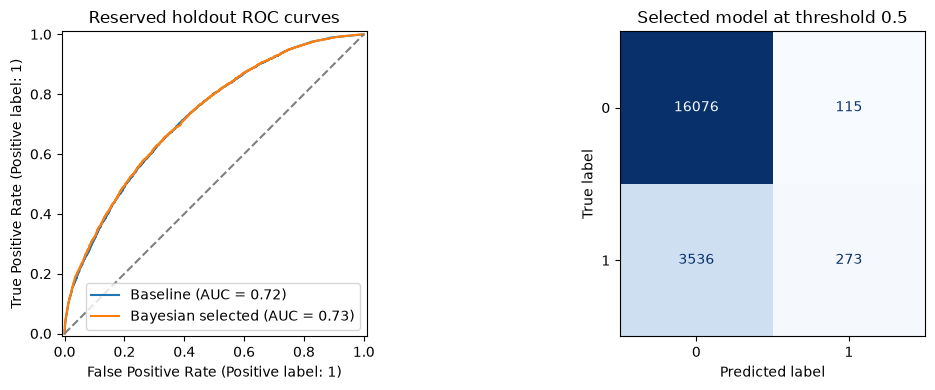

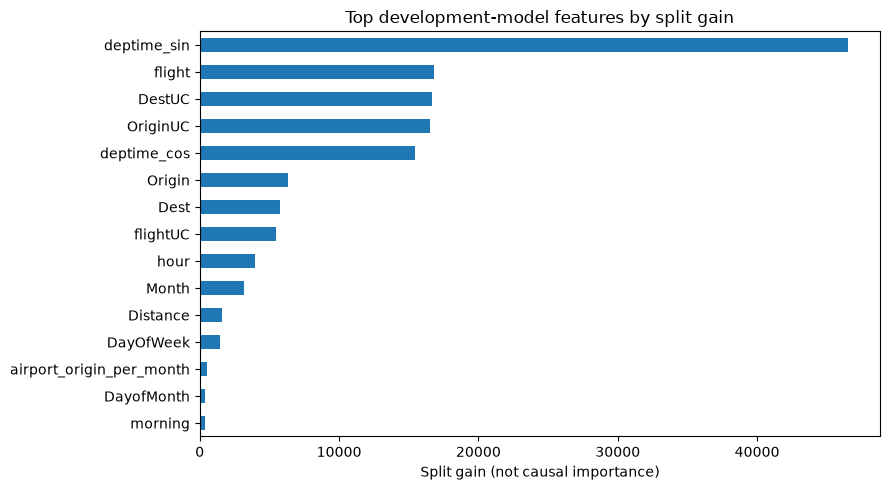

In [23]:
fig,axes = plt.subplots(1,2,figsize=(12,4))
for name,prob in holdout_predictions.items():
    RocCurveDisplay.from_predictions(y_holdout,prob,name=name,ax=axes[0])
axes[0].plot([0,1],[0,1],'--',color='gray');axes[0].set_title('Reserved holdout ROC curves')
ConfusionMatrixDisplay.from_predictions(y_holdout,holdout_predictions['Bayesian selected']>=0.5,ax=axes[1],colorbar=False,cmap='Blues')
axes[1].set_title('Selected model at threshold 0.5')
plt.tight_layout();plt.show()
importance = pd.Series(selected_model.feature_importance(importance_type='gain'),index=X_train.columns).sort_values().tail(15)
importance.plot.barh(figsize=(9,5),title='Top development-model features by split gain')
plt.xlabel('Split gain (not causal importance)');plt.tight_layout();plt.show()


## Refit and generate unlabeled-test predictions
After evaluation, refit the selected configuration on all 100,000 labeled rows with its fixed CV-selected round count. Fit feature maps on these labeled rows only and apply them to the separate test file. Preserve test row order. The output is one delay probability per row, not known labels. The evaluation above describes the development-trained model; the all-labeled refit has no separately measured test score.


In [24]:
all_labeled_state = fit_feature_state(labeled_features)
X_all = transform_features(labeled_features,all_labeled_state)
X_submission = transform_features(unlabeled_features,all_labeled_state)
final_model = train_fixed(X_all,y_train,best_params,selected_rounds)
test_probability = final_model.predict(X_submission,num_threads=N_THREADS)
assert len(test_probability)==len(test_df) and np.isfinite(test_probability).all()
assert ((test_probability>=0)&(test_probability<=1)).all()
assert 'dep_delayed_15min' not in X_all.columns
assert all(set(fold_y.index).isdisjoint(valid_y.index) for _,fold_y,_,valid_y in fold_cache)
assert all(set(fold_y.index).isdisjoint(holdout_idx) for _,fold_y,_,_ in fold_cache)
assert development_state['n_fit']==80000 and all_labeled_state['n_fit']==100000
probe = labeled_features.head(1).copy();probe.loc[:,'Origin']='UNSEEN_AIRPORT'
probe_out = transform_features(probe,all_labeled_state)
assert probe_out.Origin.iloc[0]==-1 and probe_out.airport_origin_count.iloc[0]==0
output_dir=Path('outputs');output_dir.mkdir(exist_ok=True)
pd.DataFrame({'dep_delayed_15min':test_probability}).to_csv(output_dir/'flight_delay_probabilities.csv',index=False)
search_history.to_csv(output_dir/'bayesian_search_history.csv',index=False)
comparison.to_csv(output_dir/'model_comparison.csv',index=False)
(output_dir/'best_parameters.json').write_text(json.dumps({'effective_parameters':best_params,'boosting_rounds':selected_rounds,'seed':SEED,'max_rounds':MAX_ROUNDS},indent=2))
print('Integrity checks passed. Saved 100,000 test probabilities and search/evaluation reports to outputs/.')
print('Selected CV ROC-AUC:',lgbBO.max['target'])
print('Selected holdout ROC-AUC:',comparison.loc[comparison.model.eq('Bayesian selected'),'holdout_roc_auc'].iloc[0])
if any(MAX_ROUNDS in r['best_iterations'] for r in trial_records):
    print('Some folds reached the round cap; a larger prespecified budget might improve performance.')


Integrity checks passed. Saved 100,000 test probabilities and search/evaluation reports to outputs/.
Selected CV ROC-AUC: 0.7192583429123722
Selected holdout ROC-AUC: 0.7266249676775434


## Observed results

The selected model uses **50 leaves**, **max depth 10**, **L1=5.0**, **L2≈3.9723**, and **minimum 73 observations per leaf**, with **37 boosting rounds** selected from the median fold best iterations.

| Model | Mean CV ROC-AUC | Holdout ROC-AUC | Holdout average precision |
|---|---:|---:|---:|
| Baseline | 0.71839 | 0.72573 | 0.40398 |
| Bayesian selected | 0.71974 | 0.72594 | 0.40730 |

The holdout AUC gain of about **0.00021** does not establish a meaningful advantage; no significance test was performed. At threshold 0.5, the selected model detects **224 of 3,809 delayed flights** (recall ≈5.9%). Its roughly 82% accuracy therefore hides weak delayed-flight detection. Any threshold tuning should use development data and operational error costs, not this holdout.

Some selected parameters lie at search boundaries. Seven trials explore little of this five-dimensional space; further development-only experiments may be useful but do not guarantee improvement.

**Verification:** all 24 code cells passed twice in fresh Python/IPython processes in an isolated environment. The first run verified automatic installation with lightgbm and bayes_opt initially absent; the second verified the already-installed path. This does not reproduce a separate Jupyter kernel or the user's exact local environment.


## Conclusions and limitations

The printed table compares baseline and tuned results without assuming optimization must improve the holdout score. The best observed configuration maximizes the chosen CV objective among only seven trials. Acquisition-based search uses earlier evaluations to propose later points, unlike a fixed grid or entirely random search.

The random split is appropriate for this classroom comparison but does not demonstrate future-flight generalization. Complete dates/year and a verified scheduled departure field are needed for a realistic temporal experiment. Frequency features reflect counts in the supplied sample, not actual airport traffic volume; fold and final-refit sample sizes differ. Departure-time availability must be resolved before any advance-prediction claim. Native split-gain importance is associative and can favor high-cardinality features.

### References
- [BayesianOptimization basic tour](https://bayesian-optimization.github.io/BayesianOptimization/master/basic-tour.html)
- [LightGBM parameters and aliases](https://lightgbm.readthedocs.io/en/stable/Parameters.html)
- Uploaded Springboard notebook and flight CSVs.

